# Week 5 Practice and Comprehensive Questions Solutions

In [ ]:
# Please load in advance as we will use later
# Data processing, processing and analysis library
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series,DataFrame
import pandas as pd

# Visualization Library
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

# Machine Learning Library
import sklearn

# Displayed to 3 decimal places
%precision 3

'%.3f'

####  <Practice Question 5-1>

We will use the car price data utilized in the main text. For this data, set the target variable as `price` and use `length` and `engine-size` as the explanatory variables to build a multiple regression model. When doing this, use `train_test_split` to split the data into training and test sets so that each set is half of the total data. Then, construct the model and calculate the model's score using the test data. When executing `train_test_split`, set the `random_state` option to 0.

In [ ]:
# Acquire of automobile price data
import requests, zipfile
import io

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
res = requests.get(url).content
auto = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
auto.columns =['symboling', 'normalized-losses', 'make', 'fuel-type' , 'aspiration', 'num-of-doors',
                            'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height',
                            'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore',
                            'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

In [ ]:
# Answer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data Preprocessing
auto = auto[['price', 'length', 'engine-size']]
auto = auto.replace('?', np.nan).dropna()
auto.shape

# Split data for training and validation
X = auto.drop('price', axis=1)
y = auto['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Model construction and evaluation
model = LinearRegression()
model.fit(X_train, y_train)
print('Coefficient of determination(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Coefficient of determination(test):{:.3f}'.format(model.score(X_test, y_test)))

Coefficient of determination(train):0.771
Coefficient of determination(test):0.763


####  <Practice Question 5-2>

For the data from <Practice Question 5-1>, use the same target variable, `price`, but construct a multiple regression model using a different set of explanatory variables. Split the data so that half is used for training and half for testing, then calculate the model's score using the test data. When splitting the data into training and test sets, set the `random_state` function to 0. How has the model's result changed? Try to analyze and discuss the reasons for the change.

＜Answer pframe＞

The variables are set as follows in the explanation code section, try setting `horsepower`, `width` and `height` to different variables and run it.

`auto[['price', 'horsepower', 'width', 'height']]`

In [ ]:
# Acquire of automobile price data
import requests, zipfile
import io

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
res = requests.get(url).content
auto = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
auto.columns =['symboling', 'normalized-losses', 'make', 'fuel-type' , 'aspiration', 'num-of-doors',
                            'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height',
                            'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore',
                            'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

In [ ]:
# Answer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data Preprocessing
auto = auto[['price', 'horsepower', 'width', 'height']]
auto = auto.replace('?', np.nan).dropna()
auto.shape

# Split data for training and validation
X = auto.drop('price', axis=1)
y = auto['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Model construction and evaluation
model = LinearRegression()
model.fit(X_train, y_train)
print('Coefficient of determination(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Coefficient of determination(test):{:.3f}'.format(model.score(X_test, y_test)))

Coefficient of determination(train):0.733
Coefficient of determination(test):0.737


# Comments
1. Model performance change
- If R² improves → selected features better explain price
- If R² drops → features are less informative or noisy
- If train ≫ test → overfitting
- If both low → underfitting

2. Feature selection
- Strong predictors like: engine-size, horsepower, curb-weight, usually improve performance
- Weak or irrelevant features → reduce accuracy

####  <Practice Question 5-3>
Use the `load_breast_cancer` function from the `sklearn.datasets` module to load the breast cancer dataset. Use `cancer.target` as the target variable and `cancer.data` as the explanatory variables to build a logistic regression prediction model. Use `train_test_split(random_state=0)` to split the data into training and test sets, and then calculate the score on the test data.

In [ ]:
# Answer
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=0)

model = LogisticRegression()
model.fit(X_train,y_train)
print('Correct answer rate(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Correct answer rate(test):{:.3f}'.format(model.score(X_test, y_test)))

Correct answer rate(train):0.960
Correct answer rate(test):0.930


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Comments
That warning is common when using logistic regression in scikit-learn—it simply means the optimizer didn’t fully converge within the default number of iterations. It’s not a crash, but your model may not be optimal yet.

####  <Practice Question 5-4>
Using the same settings as in <Practice Questoin 5-3>, stanardize the features of the same dataset and build the model. Then, compare the results with those from the previous question.

In [ ]:
# Answer
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

model = LogisticRegression()
model.fit(X_train_std, y_train)
print('Correct answer rate(train):{:.3f}'.format(model.score(X_train_std, y_train)))
print('Correct answer rate(test):{:.3f}'.format(model.score(X_test_std, y_test)))

Correct answer rate(train):0.991
Correct answer rate(test):0.958


# Comments
1. Standardization (Z-score scaling)

Transforms data to have mean = 0 and standard deviation = 1

Characteristics:
- Centered around 0
- Values are not bounded (can be negative or >1)
- Preserves outliers (doesn’t squash them)

When to use:
- Models assuming Gaussian-like data
- Linear models (Linear/Logistic Regression)
- SVM, PCA


2. Normalization (Min-Max scaling)

Scales data to a fixed range, usually [0, 1]
Characteristics:
- Bounded range (e.g., 0 to 1)
- Sensitive to outliers (they stretch the scale)
- Keeps relative shape of distribution

When to use:
- Neural networks (especially with bounded activations)
- Distance-based models (KNN, clustering)
- When you need fixed range inputs

####  <Practice Question 5-5>
Using the `load_breast_cancer` function from the `sklearn.datasets` module, load the breast cancer data. Set `cancer.target` as the target variable and `cancer.data` as the explanatory variable, then build a decision tree model and check the training and test scores. Try adjusting parameters, such as the depth of the tree, and compare the results.


In [ ]:
# Answer
from sklearn.tree import  DecisionTreeClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify = cancer.target, random_state=66)

models = {
    'tree1': DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0),
    'tree2': DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0),
    'tree3': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0),
    'tree4': DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0),
    'tree5': DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=0),
    'tree6': DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=0)
}

scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train')] = model.score(X_train, y_train)
    scores[(model_name, 'test')] = model.score(X_test, y_test)

pd.Series(scores).unstack()

,test,train
tree1,0.930070,0.971831
tree2,0.902098,0.997653
tree3,0.902098,1.000000
tree4,0.923077,0.974178
tree5,0.895105,1.000000
tree6,0.895105,1.000000


# Comments
1. What stratify=cancer.target does

It ensures that both training and test sets have the same proportion of each class as the original dataset.

2. Effect of max_depth

Depth = 3
- Train score: moderate
- Test score: often good
- → ✅ Good generalization (simple model)

Depth = 5
- Train score: higher
- Test score: similar or slightly better
- → ✅ Often best balance

Depth = 10
- Train score: very high (often ~1.0)
- Test score: may drop
- → ⚠️ Overfitting

Key idea:
- As depth increases → model memorizes training data → generalization worsens

####  <Practice Question 5-6>

Evaluate the Lasso regression on the data used in Practice Question 5-1. Use the `Lasso` class from the `sklearn_linear` model module. The Lasso class has parameters that can be configured, so please look into it. Specifically, refer to the official documentation below:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

In [ ]:
# Answer
from sklearn.linear_model import LinearRegression, Lasso

X = auto.drop('price', axis=1)
y = auto['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

models = {
    'linear': LinearRegression(),
    'lasso1':  Lasso(alpha=1.0, random_state=0),
    'lasso2':  Lasso(alpha=200.0, random_state=0)
}

scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train')] = model.score(X_train, y_train)
    scores[(model_name, 'test')] = model.score(X_test, y_test)

pd.Series(scores).unstack()

,test,train
lasso1,0.737107,0.733358
lasso2,0.743235,0.733082
linear,0.737069,0.733358


####  <Practice Question 5-7>
Construct and validate a k-NN model using the mushroom data we used in section 5.5 'Decision Trees.' Please execute it while changing the k parameter.

In [ ]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content

mush = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
mush.columns = [
    'classes', 'cap_shape', 'cap_surface', 'cap_color', 'odor', 'bruises',
    'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape',
    'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring',
    'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color',
    'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat'
]

mush_dummy = pd.get_dummies(mush[['gill_color', 'gill_attachment', 'odor', 'cap_color']])
mush_dummy['flg'] = mush['classes'].map(lambda x: 1 if x == 'p' else 0)

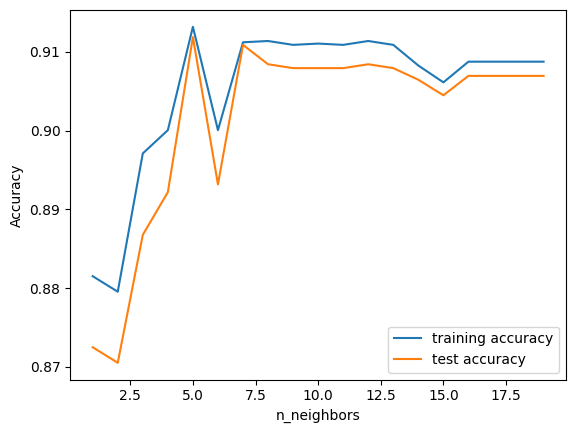

In [ ]:
# Answer
from sklearn.neighbors import  KNeighborsClassifier

# Explanatory and Objective Variables
X = mush_dummy.drop('flg', axis=1)
y = mush_dummy['flg']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=50)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)
for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.legend()

####  <Practice Question 5-8>
Using the student test result data (student-mat.csv) we used earlier, define the target variable as `G3` and the explanatory variables as X (using the students' attribute data). Change the k parameter of k-NN and consider which k is optimal.

Since the target variable is numeric and this is a regression task, please use `KNeighborsRegressor`. In regression, the output will be the average of the k nearest neighbors' values.

In [ ]:
# Import
import requests, zipfile
import os

# Specify the url where the data is located
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'

# Acquire data from the url
r = requests.get(url, stream=True)

# Extract student-mat.csv in the zipfile to the data directory in the current directory
with zipfile.ZipFile(io.BytesIO(r.content)) as existing_zip:
    existing_zip.extract('student-mat.csv', 'data')

# Directory where csvfile exists
data_dir = './data'

# Get path of student-mat.csv
path = os.path.join(data_dir, 'student-mat.csv')

student = pd.read_csv(path, sep=';')
X = student.loc[:, ['age', 'Medu', 'Fedu', 'traveltime', 'studytime'
                              , 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc'
                              , 'absences', 'G1', 'G2']].values

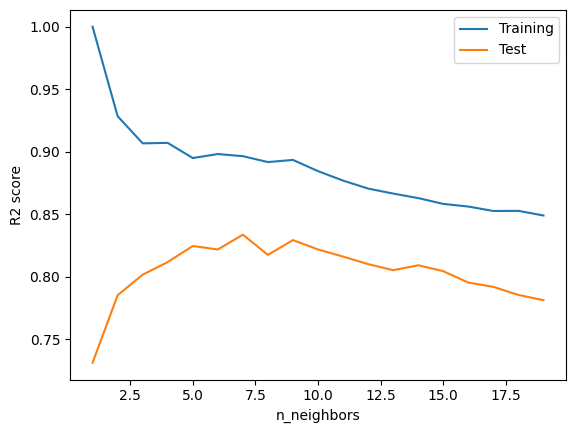

In [ ]:
# Answer
from sklearn.neighbors import  KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, student.G3, random_state=0)

scores_train = []
scores_test = []
neighbors_settings = range(1, 20)
for n_neighbors in neighbors_settings:
    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    scores_train.append(model.score(X_train, y_train))
    scores_test.append(model.score(X_test, y_test))

plt.plot(neighbors_settings, scores_train, label='Training')
plt.plot(neighbors_settings, scores_test, label='Test')
plt.ylabel('R2 score')
plt.xlabel('n_neighbors')
plt.legend()

####  <Practice Question 5-9>

Using the breast ccancer dataset, build a model to predict `cancer.target` with teh `SVC` class from the `sklearn.svm` module. Set the model as `model = SVC(kernel='rbf', random_state=0, C=2)`. After building the model, split the data into training and test sets, standardize them, and check the scores.

In [ ]:
# Answer
from sklearn.svm import SVC

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify = cancer.target, random_state=50)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

model = SVC(kernel='rbf', random_state=0, C=2)
model.fit(X_train_std, y_train)
print('Correct answer rate(train):{:.3f}'.format(model.score(X_train_std, y_train)))
print('Correct answer rate(test):{:.3f}'.format(model.score(X_test_std, y_test)))

Correct answer rate(train):0.988
Correct answer rate(test):0.986


## 5.8 Comprehensive Question

### ■ Comprehensive Question 5-1 Terms of supervised learning (1)
Answers abbreviated

### ■ Comprehensive Question 5-2 Decision Tree
Using the `load_iris` function from the `sklearn.datasets` module, load the Iris flower dataset. Set the target variable as `iris.target` and the feature variables as `iris.data`. Use a decision tree model to perform predictions and validation.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, stratify = iris.target, random_state=0)

model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
model.fit(X_train, y_train)

print('Correct answer rate(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Correct answer rate(test):{:.3f}'.format(model.score(X_test, y_test)))

Correct answer rate(train):0.964
Correct answer rate(test):0.947


### ■ Comprehensive Question 5-3 No Free Lunch

So far, we've worked with various datasets, such as math test scores and breast cancer data. Using these datasets, try applying the models we've covered—such as logistic regression and SVM—and check which model achieves the highest score. You'll find that the model with the best score varies depending on the data. Consider the characteristics of the models that perform best for each dataset. This concept is known as the "No Free Lunch" theorem, meaning that no single model is universally the best for all types of data.

In [ ]:
# Answer
# Load the necessary libraries
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.tree import  DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC

# Use breast cancer data loaded with load_breast_cancer as an example
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify = cancer.target, random_state=0)

# Standardization
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# Multiple model configurations
models = {
    'knn':  KNeighborsClassifier(),
    'tree': DecisionTreeClassifier(random_state=0),
    'logistic': LogisticRegression(random_state=0),
    'svc1': LinearSVC(random_state=0),
    'svc2': SVC(random_state=0)
}

# Empty dictionary data to have scores
scores = {}

# Scores are calculated for each model.
for model_name, model in models.items():
    model.fit(X_train_std, y_train)
    scores[(model_name, 'train')] = model.score(X_train_std, y_train)
    scores[(model_name, 'test')] = model.score(X_test_std, y_test)

# Finally, each score result is displayed
pd.Series(scores).unstack()

,test,train
knn,0.951049,0.978873
logistic,0.958042,0.990610
svc1,0.951049,0.992958
svc2,0.958042,0.992958
tree,0.902098,1.000000




---



**Acknowledgement**: Regarding the use of the following three datasets
1. http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data
2. http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
3. https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip

**References**: Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [[http://archive.ics.uci.edu/ml](http://archive.ics.uci.edu/ml)]. Irvine, CA: University of California, School of Information and Computer Science.

- Note on citation of dataset in 3:  
P. Cortez and A. Silva. Using Data Mining to Predict Secondary School Student Performance. In A. Brito and J. Teixeira Eds., Proceedings of 5th FUture BUsiness TEChnology Conference (FUBUTEC 2008) pp.5-12, Porto, Portugal, April, 2008, EUROSIS, ISBN 978-9077381-39-7.
[http://www3.dsi.uminho.pt/pcortez/student.pdf](http://www3.dsi.uminho.pt/pcortez/student.pdf)  